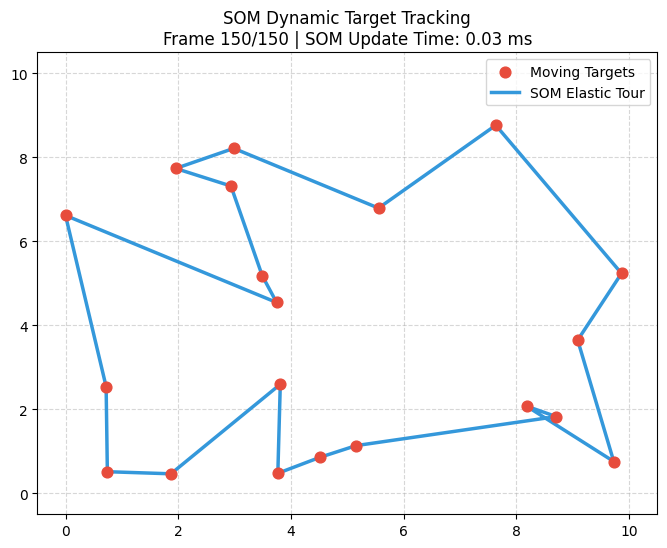

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import time
from numba import njit
from IPython.display import display, clear_output

# ––– 1. NUMBA-OPTIMIZED DYNAMIC SOM TRACKING FUNCTIONS –––––––––––––––––––––––

@njit(fastmath=True)
def init_neurons(coords, m):
    """Initializes neurons in a small circle around the center of the cities."""
    xs = coords[:, 0]
    ys = coords[:, 1]
    center_x = np.mean(xs)
    center_y = np.mean(ys)
    
    neurons = np.empty((m, 2))
    r = 0.05 * (np.max(xs) - np.min(xs))
    for i in range(m):
        angle = 2.0 * np.pi * i / m
        neurons[i, 0] = center_x + r * np.cos(angle)
        neurons[i, 1] = center_y + r * np.sin(angle)
    return neurons

@njit(fastmath=True)
def track_tsp_som(coords, neurons, epochs=5, lr_init=0.2):
    """
    Updates the existing neural ring locally to track moving targets.
    By using only a few epochs (e.g., 5) and a small neighborhood radius,
    the ring deforms locally to follow coordinate drift.
    """
    n = len(coords)
    m = len(neurons)
    
    # We restrict the neighborhood to a very small local radius
    sigma = m / 30.0 
    if sigma < 1.0:
        sigma = 1.0
        
    limit = int(3.0 * sigma) + 1
    h_table = np.empty(limit + 1)
    two_sigma_sq = 2.0 * sigma * sigma
    for offset in range(limit + 1):
        h_table[offset] = np.exp(-(offset * offset) / two_sigma_sq)
        
    for epoch in range(epochs):
        pct = epoch / epochs
        lr = lr_init * (1.0 - pct)
        
        shuffled_indices = np.random.permutation(n)
        for city_idx in shuffled_indices:
            city_x = coords[city_idx, 0]
            city_y = coords[city_idx, 1]
            
            # Find BMU
            bmu_idx = 0
            min_dist_sq = np.inf
            for j in range(m):
                dx = neurons[j, 0] - city_x
                dy = neurons[j, 1] - city_y
                d_sq = dx*dx + dy*dy
                if d_sq < min_dist_sq:
                    min_dist_sq = d_sq
                    bmu_idx = j
            
            # Update BMU and neighbors locally
            for offset in range(-limit, limit + 1):
                j = (bmu_idx + offset) % m
                h = h_table[np.abs(offset)]
                neurons[j, 0] += lr * h * (city_x - neurons[j, 0])
                neurons[j, 1] += lr * h * (city_y - neurons[j, 1])
                
    # Reconstruct Tour
    city_to_neuron = np.empty(n, dtype=np.int32)
    for i in range(n):
        city_x = coords[i, 0]
        city_y = coords[i, 1]
        bmu_idx = 0
        min_dist_sq = np.inf
        for j in range(m):
            dx = neurons[j, 0] - city_x
            dy = neurons[j, 1] - city_y
            d_sq = dx*dx + dy*dy
            if d_sq < min_dist_sq:
                min_dist_sq = d_sq
                bmu_idx = j
        city_to_neuron[i] = bmu_idx
        
    sorted_indices = np.argsort(city_to_neuron)
    
    circuit = np.empty(n + 1, dtype=np.int32)
    for i in range(n):
        circuit[i] = sorted_indices[i]
    circuit[n] = sorted_indices[0]
    
    return circuit, neurons


# ––– 2. PHYSICAL ENVIRONMENT (BOUNCING TARGETS) –––––––––––––––––––––––––––––

n_cities = 20
m_neurons = int(1.3 * n_cities)

# Initialize static boundaries, random coordinates, and random velocities
box_min, box_max = 0.0, 10.0
coords = np.random.uniform(box_min + 1.0, box_max - 1.0, size=(n_cities, 2))
velocities = np.random.uniform(-0.15, 0.15, size=(n_cities, 2))

# Initial training to lock the ring onto the initial positions
neurons = init_neurons(coords, m_neurons)
# Run a standard initialization (e.g., 100 epochs) to settle the ring first
circuit, neurons = track_tsp_som(coords, neurons, epochs=100, lr_init=0.8)

# Setup the real-time Matplotlib figure
fig, ax = plt.subplots(figsize=(8, 6))

print("Compiling JIT functions... (Animation will start in a moment)")

# ––– 3. DYNAMIC TARGET TRACKING SIMULATION LOOP –––––––––––––––––––––––––––––

n_frames = 150
for frame in range(n_frames):
    # 1. Update target positions (Physics step: move and bounce off boundaries)
    coords += velocities
    for i in range(n_cities):
        # Bounce off X boundaries
        if coords[i, 0] < box_min or coords[i, 0] > box_max:
            velocities[i, 0] *= -1.0
            coords[i, 0] = np.clip(coords[i, 0], box_min, box_max)
        # Bounce off Y boundaries
        if coords[i, 1] < box_min or coords[i, 1] > box_max:
            velocities[i, 1] *= -1.0
            coords[i, 1] = np.clip(coords[i, 1], box_min, box_max)
            
    # 2. Local adaptation (Track the target drift with only 5 epochs!)
    start_time = time.perf_counter()
    circuit, neurons = track_tsp_som(coords, neurons, epochs=5, lr_init=0.3)
    track_time = (time.perf_counter() - start_time) * 1000  # in milliseconds
    
    # 3. Plotting the frame
    ax.clear()
    
    # Plot moving targets
    ax.scatter(coords[:, 0], coords[:, 1], color='#e74c3c', s=60, zorder=3, label='Moving Targets')
    
    # Plot the active neural tracking ring
    tour_coords = coords[circuit]
    ax.plot(tour_coords[:, 0], tour_coords[:, 1], color='#3498db', linewidth=2.5, zorder=2, label='SOM Elastic Tour')
    
    # Format Plot
    ax.set_xlim(box_min - 0.5, box_max + 0.5)
    ax.set_ylim(box_min - 0.5, box_max + 0.5)
    ax.set_title(f"SOM Dynamic Target Tracking\nFrame {frame+1}/{n_frames} | SOM Update Time: {track_time:.2f} ms", fontsize=12)
    ax.legend(loc='upper right')
    ax.grid(True, linestyle='--', alpha=0.5)
    
    # Render frame in Jupyter
    display(fig)
    clear_output(wait=True)
    # time.sleep(0.01)  # Control animation speed

plt.close()